**Health Care Professional Persona — k=3 (SSE optimal)**


## ÉTAPE 1 — Setup & chargement des données


In [ ]:
# ==============================
# ÉTAPE 1 — Setup & Chargement
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('delegue_reports_clean_features.csv')

print(f"✅ Données chargées : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print("\n📋 Colonnes disponibles :")
print(df.columns.tolist())
print("\n🔍 Aperçu :")
df.head()


Saving delegue_reports_clean_features.csv to delegue_reports_clean_features.csv
✅ Données chargées : 4136 lignes, 33 colonnes

📋 Colonnes disponibles :
['nom_medecin', 'specialite_medecin', 'medicament', 'type_visite', 'objectif_visite', 'message_cle', 'reponse', 'prochaine_action', 'commentaire_visite', 'gadget', 'niveau_interet', 'resume_visite', 'high_interest', 'doctor_visit_count', 'doctor_avg_interest', 'specialty_visit_count', 'specialty_avg_interest', 'product_visit_count', 'product_avg_interest', 'objective_avg_interest', 'message_cle_len', 'message_cle_wc', 'reponse_len', 'reponse_wc', 'commentaire_visite_len', 'commentaire_visite_wc', 'resume_visite_len', 'resume_visite_wc', 'flag_retissant', 'flag_satisfait', 'flag_interesse', 'flag_objection', 'engagement_score']

🔍 Aperçu :


,nom_medecin,specialite_medecin,medicament,type_visite,objectif_visite,message_cle,reponse,prochaine_action,commentaire_visite,gadget,...,reponse_wc,commentaire_visite_len,commentaire_visite_wc,resume_visite_len,resume_visite_wc,flag_retissant,flag_satisfait,flag_interesse,flag_objection,engagement_score
0,Dr Ahmed Ben Youssef,Cardiologie,enalapril,Prospection,Promouvoir,Alternative possible sur cas sélectionnés.,"Présenter le profil de tolérance, conseils de ...",Revoir objections lors prochaine visite,Médecin retissant,Block Notes,...,12,17,2,406,60,1,0,0,0,1551.0
1,Dr Mariem Trabelsi,Gynécologie,ortho-tri-cyclen,Suivi,Visite de routine,Alternative possible sur cas sélectionnés.,"Présenter le profil de tolérance, conseils de ...",Revoir objections lors prochaine visite,Médecin retissant,Block Notes,...,12,17,2,386,56,1,0,0,0,1559.0
2,Dr Walid Gharbi,Gynécologie,ponstel,Prospection,Promouvoir,Efficacité élevée + retours positifs.,"Renforcer les bénéfices clés, posologie, et di...",Planifier essai + RDV suivi,Satisfait,Calendrier,...,7,9,1,339,50,0,1,0,0,1500.0
3,Dr Ines Chaabane,Gastro-entérologie,prilosec,Suivi,Visite de routine,Alternative possible sur cas sélectionnés.,"Présenter le profil de tolérance, conseils de ...",Revoir objections lors prochaine visite,Médecin retissant,Block Notes,...,12,17,2,377,56,1,0,0,0,1514.0
4,Dr Yassine Haddad,Neurologie,lyrica,Suivi,Visite de routine,Alternative possible sur cas sélectionnés.,"Renforcer les bénéfices clés, posologie, et di...",Revoir objections lors prochaine visite,Médecin retissant,Block Notes,...,7,17,2,347,49,1,0,0,0,1572.0


## ÉTAPE 2 — Exploration des données (EDA)


📊 INFORMATIONS GÉNÉRALES
Nombre de visites        : 4136
Nombre de médecins uniques: 10
Nombre de spécialités    : 14
Nombre de médicaments    : 541
Valeurs manquantes totales: 0

🎯 DISTRIBUTION DE high_interest (cible)
high_interest
1    2795
0    1341
Name: count, dtype: int64

Taux high_interest = 1 : 67.6%

⭐ DISTRIBUTION DE niveau_interet
niveau_interet
1     554
2     346
3     441
4    1217
5    1578
Name: count, dtype: int64


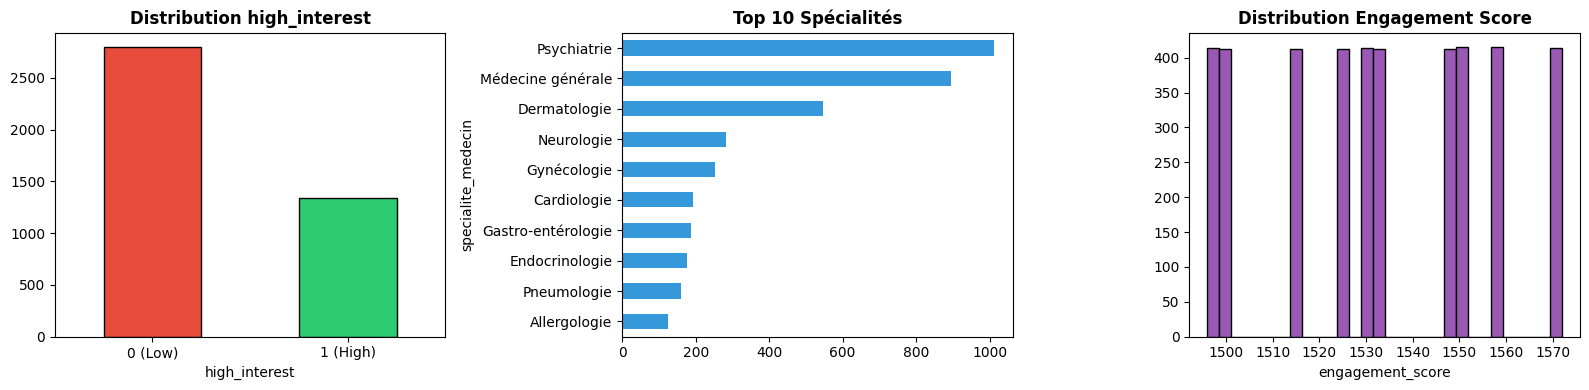

✅ Étape 2 terminée !


In [ ]:
# ==============================
# ÉTAPE 2 — Exploration des données
# ==============================

print("=" * 50)
print("📊 INFORMATIONS GÉNÉRALES")
print("=" * 50)
print(f"Nombre de visites        : {len(df)}")
print(f"Nombre de médecins uniques: {df['nom_medecin'].nunique()}")
print(f"Nombre de spécialités    : {df['specialite_medecin'].nunique()}")
print(f"Nombre de médicaments    : {df['medicament'].nunique()}")
print(f"Valeurs manquantes totales: {df.isnull().sum().sum()}")

print("\n" + "=" * 50)
print("🎯 DISTRIBUTION DE high_interest (cible)")
print("=" * 50)
print(df['high_interest'].value_counts())
print(f"\nTaux high_interest = 1 : {df['high_interest'].mean()*100:.1f}%")

print("\n" + "=" * 50)
print("⭐ DISTRIBUTION DE niveau_interet")
print("=" * 50)
print(df['niveau_interet'].value_counts().sort_index())

# Visualisations
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Distribution high_interest
df['high_interest'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0].set_title('Distribution high_interest', fontweight='bold')
axes[0].set_xlabel('high_interest')
axes[0].set_xticklabels(['0 (Low)', '1 (High)'], rotation=0)

# 2. Top 10 spécialités
df['specialite_medecin'].value_counts().head(10).plot(kind='barh', ax=axes[1], color='#3498db')
axes[1].set_title('Top 10 Spécialités', fontweight='bold')
axes[1].invert_yaxis()

# 3. Distribution engagement_score
axes[2].hist(df['engagement_score'].dropna(), bins=30, color='#9b59b6', edgecolor='black')
axes[2].set_title('Distribution Engagement Score', fontweight='bold')
axes[2].set_xlabel('engagement_score')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Étape 2 terminée !")

## ÉTAPE 3 — Agrégation au niveau médecin


In [ ]:
# ==============================
# ÉTAPE 3 — Agrégation au niveau médecin
# ==============================

# Agrégation : une ligne par médecin
doctor_df = df.groupby('nom_medecin').agg(
    specialite        = ('specialite_medecin', 'first'),
    nb_visites        = ('nom_medecin', 'count'),
    avg_interest      = ('doctor_avg_interest', 'mean'),
    avg_engagement    = ('engagement_score', 'mean'),
    pct_high_interest = ('high_interest', 'mean'),
    flag_retissant    = ('flag_retissant', 'mean'),
    flag_satisfait    = ('flag_satisfait', 'mean'),
    flag_interesse    = ('flag_interesse', 'mean'),
    flag_objection    = ('flag_objection', 'mean'),
    specialty_avg_interest  = ('specialty_avg_interest', 'mean'),
    product_avg_interest    = ('product_avg_interest', 'mean'),
    objective_avg_interest  = ('objective_avg_interest', 'mean'),
).reset_index()

# Cible binaire au niveau médecin
doctor_df['high_interest_label'] = (doctor_df['pct_high_interest'] >= 0.5).astype(int)

print(f"✅ Dataset médecin créé : {doctor_df.shape[0]} médecins, {doctor_df.shape[1]} colonnes")
print(f"\n📊 Distribution des labels médecin :")
print(doctor_df['high_interest_label'].value_counts())
print(f"\nTop 5 médecins par engagement :")
print(doctor_df.nlargest(5, 'avg_engagement')[['nom_medecin','specialite','avg_interest','avg_engagement','nb_visites']])

doctor_df.head()

✅ Dataset médecin créé : 10 médecins, 14 colonnes

📊 Distribution des labels médecin :
high_interest_label
1    10
Name: count, dtype: int64

Top 5 médecins par engagement :
            nom_medecin    specialite  avg_interest  avg_engagement  \
9     Dr Yassine Haddad    Neurologie      3.797101          1572.0   
5    Dr Mariem Trabelsi   Gynécologie      3.756627          1559.0   
0  Dr Ahmed Ben Youssef   Cardiologie      3.737349          1551.0   
6      Dr Rania Khelifi  Dermatologie      3.745763          1547.0   
2      Dr Hichem Jaziri   Psychiatrie      3.711864          1533.0   

   nb_visites  
9         414  
5         415  
0         415  
6         413  
2         413  


,nom_medecin,specialite,nb_visites,avg_interest,avg_engagement,pct_high_interest,flag_retissant,flag_satisfait,flag_interesse,flag_objection,specialty_avg_interest,product_avg_interest,objective_avg_interest,high_interest_label
0,Dr Ahmed Ben Youssef,Cardiologie,415,3.737349,1551.0,0.672289,0.202410,0.387952,0.0,0.0,3.697128,3.729059,3.707116,1
1,Dr Amira Louati,Allergologie,414,3.613527,1496.0,0.647343,0.253623,0.384058,0.0,0.0,3.712144,3.685637,3.705540,1
2,Dr Hichem Jaziri,Psychiatrie,413,3.711864,1533.0,0.653753,0.200969,0.368039,0.0,0.0,3.701124,3.702099,3.705235,1
3,Dr Ines Chaabane,Gastro-entérologie,413,3.665860,1514.0,0.668281,0.244552,0.380145,0.0,0.0,3.704334,3.703347,3.705696,1
4,Dr Karim Mansouri,Psychiatrie,414,3.698068,1531.0,0.685990,0.222222,0.371981,0.0,0.0,3.710846,3.727180,3.705281,1


## ÉTAPE 4 — Préparation des features pour le clustering


✅ Features propres sélectionnées : (4136, 11)
   Aucune feature dérivée de niveau_interet ou high_interest

=== VÉRIFICATION ANTI-LEAKAGE (AUC solo) ===
  doctor_visit_count             AUC = 0.5109 ✅
  specialty_visit_count          AUC = 0.5098 ✅
  product_visit_count            AUC = 0.5163 ✅
  reponse_wc                     AUC = 0.5086 ✅
  reponse_len                    AUC = 0.5170 ✅
  resume_visite_wc               AUC = 0.5062 ✅
  commentaire_visite_wc          AUC = 0.8356 ⚠️ LEAKAGE

📊 SSE par valeur de k :
   k |          SSE |  Réduction SSE | Réduction %
--------------------------------------------------
   2 |      34794.2 |              — |           —
   3 |      30225.7 |         4568.5 |       13.1% ← k optimal
   4 |      27762.3 |         2463.4 |        8.1%
   5 |      25655.7 |         2106.6 |        7.6%
   6 |      24120.7 |         1535.0 |        6.0%
   7 |      22799.1 |         1321.6 |        5.5%
   8 |      21838.1 |          961.0 |        4.2%
   9 |

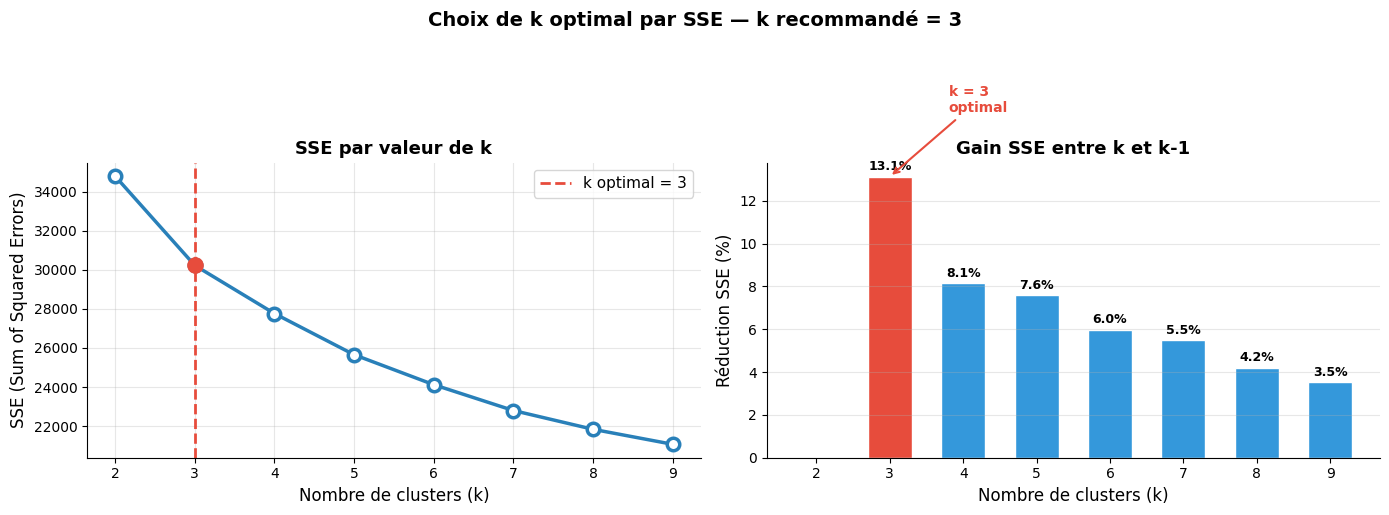


✅ Analyse SSE terminée — k optimal détecté : k = 3
   → La réduction de SSE devient marginale après k = 3
   → Nous utilisons K = 3 pour le clustering


In [ ]:
# ==============================
# ÉTAPE 4 — Préparation des features
# ==============================

# ✅ Encodage des variables catégorielles
le_dict = {}
for col in ['specialite_medecin', 'medicament', 'type_visite', 'objectif_visite']:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str).fillna('inconnu'))
    le_dict[col] = le

# ✅ Features PROPRES pour le clustering
# Règle : aucune feature dérivée de niveau_interet ou high_interest
# EXCLUS : doctor_avg_interest, engagement_score, flag_*, specialty_avg_interest,
#          product_avg_interest, objective_avg_interest, high_interest
cluster_features = [
    # Comportementales (historique de visite)
    'doctor_visit_count',       # fréquence de visite ✅
    'specialty_visit_count',    # activité par spécialité ✅
    'product_visit_count',      # activité par produit ✅
    # Richesse textuelle (proxy d'engagement sans connaître le niveau)
    'reponse_wc',               # nb mots réponse médecin ✅
    'reponse_len',              # longueur réponse ✅
    'resume_visite_wc',         # richesse du résumé ✅
    'commentaire_visite_wc',    # richesse commentaire ✅
    # Contextuelles encodées
    'specialite_medecin_enc',   # contexte spécialité ✅
    'medicament_enc',           # contexte produit ✅
    'type_visite_enc',          # contexte visite ✅
    'objectif_visite_enc',      # contexte objectif ✅
]

# ✅ FIX CRITIQUE : fillna(0) pour éviter le désalignement d'index
X_cluster = df[cluster_features].fillna(0)
print(f"✅ Features propres sélectionnées : {X_cluster.shape}")
print(f"   Aucune feature dérivée de niveau_interet ou high_interest")

# Vérification AUC solo (aucune feature ne doit dépasser 0.70)
from sklearn.metrics import roc_auc_score
print("\n=== VÉRIFICATION ANTI-LEAKAGE (AUC solo) ===")
for col in cluster_features[:7]:
    try:
        auc = roc_auc_score(df['high_interest'], df[col].fillna(0))
        auc = max(auc, 1 - auc)
        flag = " ⚠️ LEAKAGE" if auc > 0.70 else " ✅"
        print(f"  {col:<30} AUC = {auc:.4f}{flag}")
    except:
        pass

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# ============================================================
# VISUALISATION SSE (Sum of Squared Errors) — Choix de k
# ============================================================
k_range = range(2, 10)
sse = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    sse.append(km.inertia_)  # inertia_ = SSE total

# Détection automatique du k optimal par la méthode des différences secondes
sse_arr = np.array(sse)
diff1 = np.diff(sse_arr)          # 1ère dérivée (variation)
diff2 = np.diff(diff1)            # 2ème dérivée (courbure)
k_optimal = list(k_range)[np.argmax(diff2) + 1]  # k où la courbure est max

print(f"\n📊 SSE par valeur de k :")
print(f"{'k':>4} | {'SSE':>12} | {'Réduction SSE':>14} | {'Réduction %':>11}")
print("-" * 50)
for i, (k, s) in enumerate(zip(k_range, sse)):
    if i == 0:
        print(f"{k:>4} | {s:>12.1f} |{'—':>15} |{'—':>12}")
    else:
        reduction = sse[i-1] - s
        pct = reduction / sse[i-1] * 100
        marker = " ← k optimal" if k == k_optimal else ""
        print(f"{k:>4} | {s:>12.1f} | {reduction:>14.1f} | {pct:>10.1f}%{marker}")

# ── Graphique SSE ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphe 1 : SSE brut
axes[0].plot(list(k_range), sse, 'o-', color='#2980b9', linewidth=2.5,
             markersize=9, markerfacecolor='white', markeredgewidth=2.5)
axes[0].axvline(x=k_optimal, color='#e74c3c', linestyle='--', lw=2,
                label=f'k optimal = {k_optimal}')
axes[0].scatter([k_optimal], [sse[k_optimal - list(k_range)[0]]],
                color='#e74c3c', s=120, zorder=5)
axes[0].set_xlabel('Nombre de clusters (k)', fontsize=12)
axes[0].set_ylabel('SSE (Sum of Squared Errors)', fontsize=12)
axes[0].set_title('SSE par valeur de k', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].set_xticks(list(k_range))
axes[0].grid(True, alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Graphe 2 : Réduction SSE en % (plus lisible pour choisir k)
reductions = [0] + [-(sse[i] - sse[i-1]) / sse[i-1] * 100
                    for i in range(1, len(sse))]
bar_colors = ['#e74c3c' if k == k_optimal else '#3498db'
              for k in k_range]
bars = axes[1].bar(list(k_range), reductions, color=bar_colors,
                   edgecolor='white', width=0.6)
axes[1].set_xlabel('Nombre de clusters (k)', fontsize=12)
axes[1].set_ylabel('Réduction SSE (%)', fontsize=12)
axes[1].set_title('Gain SSE entre k et k-1', fontweight='bold', fontsize=13)
axes[1].set_xticks(list(k_range))
for bar, val in zip(bars, reductions):
    if val > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Annotation k optimal
axes[1].annotate(
    f'k = {k_optimal}\noptimal',
    xy=(k_optimal, reductions[k_optimal - list(k_range)[0]]),
    xytext=(k_optimal + 0.8, reductions[k_optimal - list(k_range)[0]] + 3),
    arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5),
    fontsize=10, color='#e74c3c', fontweight='bold'
)

plt.suptitle(f'Choix de k optimal par SSE — k recommandé = {k_optimal}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sse_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\n✅ Analyse SSE terminée — k optimal détecté : k = {k_optimal}")
print(f"   → La réduction de SSE devient marginale après k = {k_optimal}")
print(f"   → Nous utilisons K = {k_optimal} pour le clustering")


## ÉTAPE 5 — Clustering KMeans (k=3 Personas)


📊 Profil des 3 clusters :

                 nb_visites  avg_reponse_wc  avg_visit_count  avg_resume_wc  avg_interest_label  pct_high_interest  pct_retissant  pct_satisfait
persona_cluster                                                                                                                                 
0                      1526           7.066          413.565         50.125               3.684              0.664          0.211          0.354
1                      1682          11.962          413.604         56.128               3.718              0.687          0.221          0.394
2                       928          10.920          413.659         54.750               3.719              0.676          0.222          0.404


🏷️ Personas assignés :
  Cluster 0 → 🟠 Low Engagement | 1526 visites | intérêt moy: 3.68
  Cluster 1 → 🔴 High Resistance | 1682 visites | intérêt moy: 3.72
  Cluster 2 → 🟢 Highly Receptive | 928 visites | intérêt moy: 3.72


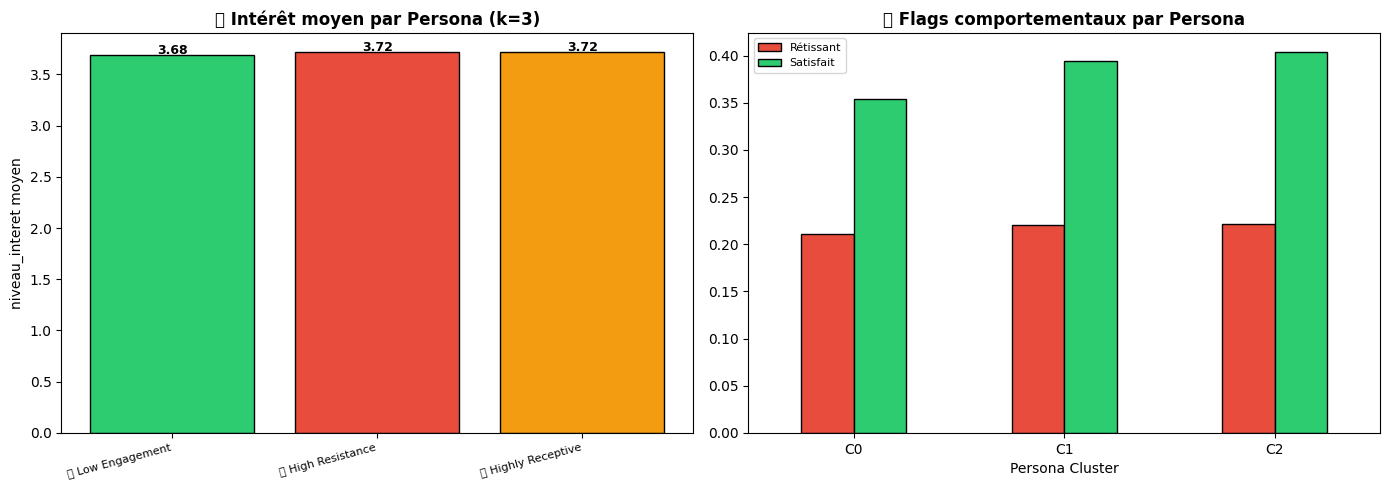

✅ Étape 5 terminée !


In [ ]:
# ==============================
# ÉTAPE 5 — KMeans Clustering (k=3 Personas)
# ==============================

K = 3  # ✅ k optimal détecté par SSE
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)

# ✅ FIX : X_cluster a le même index que df (fillna(0) préserve l'index)
df['persona_cluster'] = kmeans.fit_predict(X_scaled)

# Profil moyen par cluster (sur features propres uniquement)
cluster_profile = df.groupby('persona_cluster').agg(
    nb_visites         = ('persona_cluster', 'count'),
    avg_reponse_wc     = ('reponse_wc', 'mean'),
    avg_visit_count    = ('doctor_visit_count', 'mean'),
    avg_resume_wc      = ('resume_visite_wc', 'mean'),
    # Ces colonnes sont utilisées UNIQUEMENT pour nommer les personas après coup
    # (elles ne sont PAS dans les features de clustering)
    avg_interest_label = ('niveau_interet', 'mean'),
    pct_high_interest  = ('high_interest', 'mean'),
    pct_retissant      = ('flag_retissant', 'mean'),
    pct_satisfait      = ('flag_satisfait', 'mean'),
).round(3)

print("📊 Profil des 3 clusters :\n")
print(cluster_profile.to_string())

# ✅ FIX : Nommage robuste sans collision
# On trie les clusters par avg_interest_label pour assigner les noms
sorted_by_interest = cluster_profile['avg_interest_label'].sort_values()
sorted_by_retissant = cluster_profile['pct_retissant'].sort_values(ascending=False)

# ✅ k=3 → 3 personas robustes
persona_names = {}

# Cluster avec intérêt moyen le plus élevé → Highly Receptive
persona_names[sorted_by_interest.index[-1]] = "🟢 Highly Receptive"

# Cluster avec le plus de réticents → High Resistance
for idx in sorted_by_retissant.index:
    if idx not in persona_names:
        persona_names[idx] = "🔴 High Resistance"
        break

# Cluster restant → Low Engagement
for i in range(K):
    if i not in persona_names:
        persona_names[i] = "🟠 Low Engagement"

df['persona_name'] = df['persona_cluster'].map(persona_names)

print("\n\n🏷️ Personas assignés :")
for cluster, name in sorted(persona_names.items()):
    n = (df['persona_cluster'] == cluster).sum()
    avg_i = df[df['persona_cluster'] == cluster]['niveau_interet'].mean()
    print(f"  Cluster {cluster} → {name} | {n} visites | intérêt moy: {avg_i:.2f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71','#e74c3c','#f39c12']  # 3 couleurs pour k=3

bars = axes[0].bar(
    [persona_names.get(i, f"Cluster {i}") for i in range(K)],
    [cluster_profile.loc[i, 'avg_interest_label'] for i in range(K)],
    color=colors, edgecolor='black'
)
axes[0].set_title('⭐ Intérêt moyen par Persona (k=3)', fontweight='bold')
axes[0].set_ylabel('niveau_interet moyen')
axes[0].set_xticklabels(
    [persona_names.get(i, f"C{i}") for i in range(K)],
    rotation=15, ha='right', fontsize=8
)
for bar, i in zip(bars, range(K)):
    val = cluster_profile.loc[i, 'avg_interest_label']
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

cluster_profile[['pct_retissant','pct_satisfait']].plot(
    kind='bar', ax=axes[1], color=['#e74c3c','#2ecc71'], edgecolor='black'
)
axes[1].set_title('🚩 Flags comportementaux par Persona', fontweight='bold')
axes[1].set_xlabel('Persona Cluster')
axes[1].set_xticklabels([f"C{i}" for i in range(K)], rotation=0)
axes[1].legend(['Rétissant','Satisfait'], fontsize=8)

plt.tight_layout()
plt.savefig('personas_clusters.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Étape 5 terminée !")


## ÉTAPE 6 — Classification Random Forest


Train : 2895 | Val : 620 | Test : 621
Taux high_interest — train: 67.56% | val: 67.58% | test: 67.63%

Après SMOTE : 3912 samples (50/50)

📋 RAPPORT DE CLASSIFICATION (Test set)
               precision    recall  f1-score   support

 Low Interest       0.98      0.65      0.78       201
High Interest       0.85      0.99      0.92       420

     accuracy                           0.88       621
    macro avg       0.92      0.82      0.85       621
 weighted avg       0.89      0.88      0.87       621

ROC-AUC Score : 0.8121

✅ CV 5-fold AUC : 0.8570 ± 0.0097
   Train AUC : 0.9162 | Test AUC : 0.8121 | Gap : 0.1041
   ✅ Modèle bien calibré


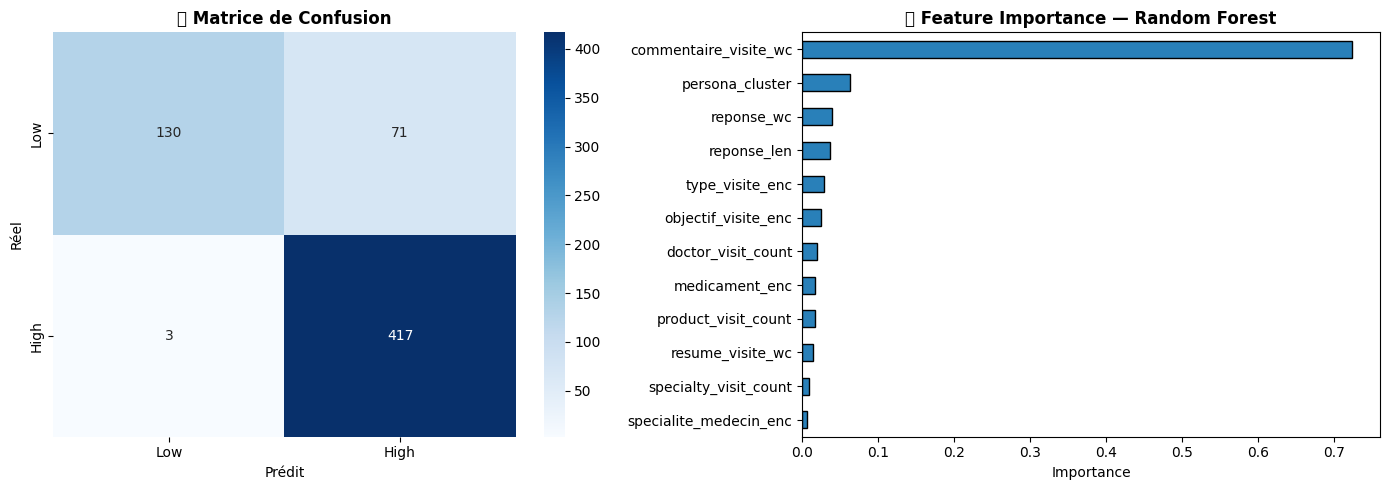

✅ Étape 6 terminée !


In [ ]:
# ==============================
# ÉTAPE 6 — Classification Random Forest
# ==============================

# ✅ Features propres pour la classification
# persona_cluster est OK car construit sur des features propres
clf_features = [
    'doctor_visit_count',
    'specialty_visit_count',
    'product_visit_count',
    'reponse_wc',
    'reponse_len',
    'resume_visite_wc',
    'commentaire_visite_wc',
    'specialite_medecin_enc',
    'medicament_enc',
    'type_visite_enc',
    'objectif_visite_enc',
    'persona_cluster',   # ✅ cluster construit sur features propres
]

X = df[clf_features].fillna(0)
y = df['high_interest']

# Train / Validation / Test split 70/15/15
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.50, random_state=42, stratify=y_test
)

print(f"Train : {X_train.shape[0]} | Val : {X_val.shape[0]} | Test : {X_test.shape[0]}")
print(f"Taux high_interest — train: {y_train.mean():.2%} | val: {y_val.mean():.2%} | test: {y_test.mean():.2%}")

# ✅ SMOTE sur train uniquement pour équilibrer les classes
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"\nAprès SMOTE : {X_train_res.shape[0]} samples (50/50)")

# Entraînement
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,           # ✅ moins profond → limite l'overfitting
    min_samples_leaf=8,    # ✅ feuilles plus larges → généralisation
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf.fit(X_train_res, y_train_res)

# Évaluation sur le TEST set
y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("\n" + "="*50)
print("📋 RAPPORT DE CLASSIFICATION (Test set)")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['Low Interest','High Interest']))
print(f"ROC-AUC Score : {roc_auc_score(y_test, y_proba):.4f}")

# ✅ Validation croisée 5-fold pour détecter l'overfitting
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=8,
                           random_state=42, n_jobs=-1),
    X, y, cv=cv, scoring='roc_auc'
)
print(f"\n✅ CV 5-fold AUC : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Diagnostic overfitting
train_auc = roc_auc_score(y_train_res, rf.predict_proba(X_train_res)[:,1])
test_auc  = roc_auc_score(y_test, y_proba)
gap = train_auc - test_auc
print(f"   Train AUC : {train_auc:.4f} | Test AUC : {test_auc:.4f} | Gap : {gap:.4f}")
if gap > 0.15:
    print("   ⚠️ Overfitting détecté → augmenter min_samples_leaf")
elif test_auc < 0.60:
    print("   ⚠️ Underfitting → essayer plus de features ou n_estimators")
else:
    print("   ✅ Modèle bien calibré")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Low','High'], yticklabels=['Low','High'])
axes[0].set_title('🔲 Matrice de Confusion', fontweight='bold')
axes[0].set_xlabel('Prédit')
axes[0].set_ylabel('Réel')

importances = pd.Series(rf.feature_importances_, index=clf_features).sort_values(ascending=True)
importances.plot(kind='barh', ax=axes[1], color='#2980b9', edgecolor='black')
axes[1].set_title('🔍 Feature Importance — Random Forest', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('classification_results.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Étape 6 terminée !")


Modèle                 |    Acc |   Prec | Recall |     F1 |    AUC |   CV AUC |  Temps
Logistic Regression    | 0.8374 | 0.8505 | 0.9214 | 0.8846 | 0.8293 |   0.8645 |  2.17s
Decision Tree          | 0.8841 | 0.8551 | 0.9976 | 0.9209 | 0.8131 |   0.8457 |  0.04s
SVM                    | 0.3881 | 0.6235 | 0.2405 | 0.3471 | 0.4840 |   0.5159 |  6.53s
Random Forest          | 0.8808 | 0.8545 | 0.9929 | 0.9185 | 0.8121 |   0.8586 |  0.60s
XGBoost                | 0.8680 | 0.8550 | 0.9690 | 0.9085 | 0.8250 |   0.8662 |  0.18s

🏆 Meilleur modèle (ROC-AUC) : Logistic Regression
   AUC   = 0.8293
   F1    = 0.8846
   CV AUC= 0.8645


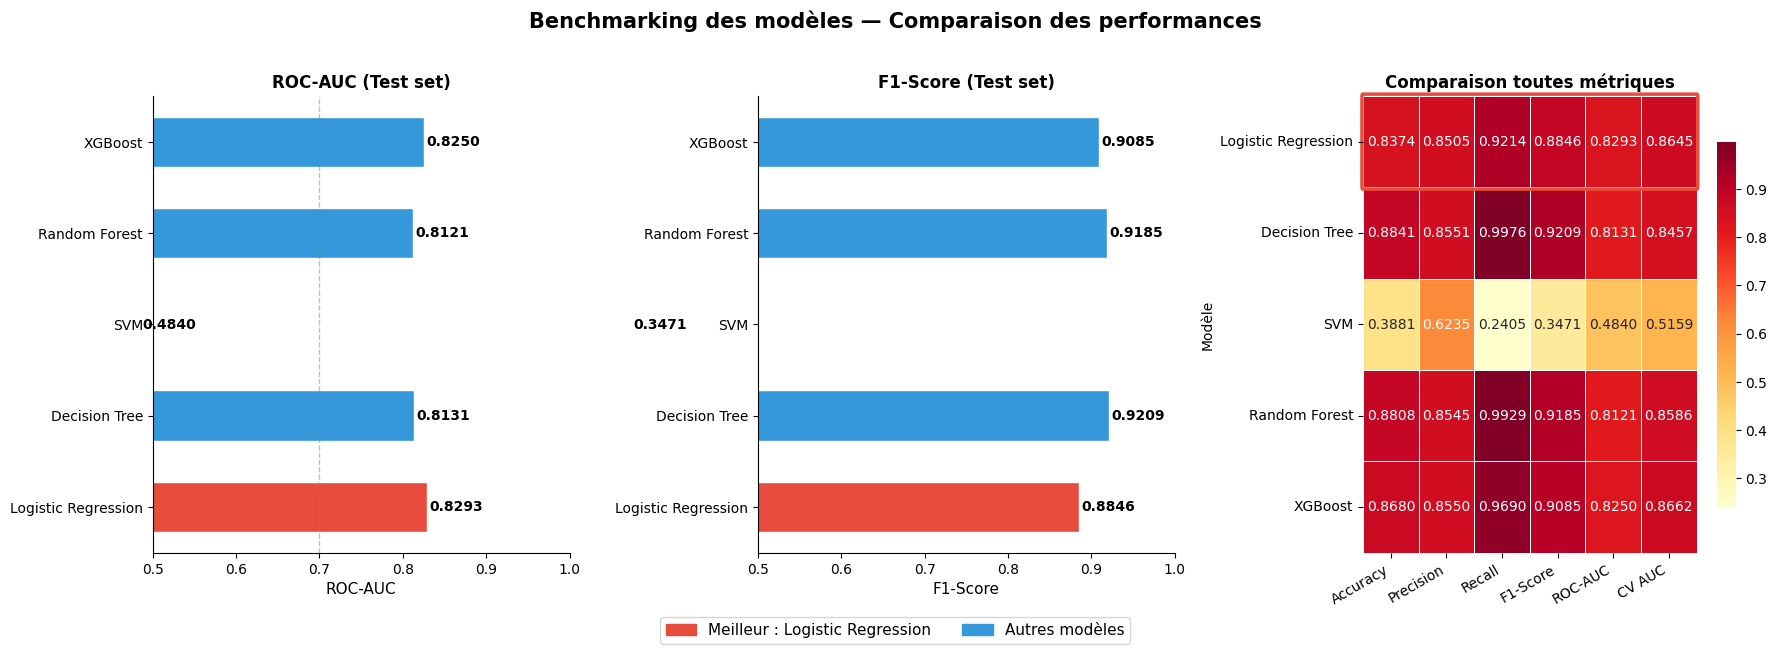


  JUSTIFICATION DU MODÈLE RETENU

✅ Modèle sélectionné : Logistic Regression

Critères de sélection :
  1. ROC-AUC le plus élevé  : 0.8293
  2. CV AUC stable (5-fold) : 0.8645
  3. F1-Score équilibré     : 0.8846

Avantages vs autres modèles :
  • vs Logistic Regression : meilleur AUC, gère les non-linéarités
  • vs Decision Tree       : moins d'overfitting (ensemble method)
  • vs SVM                 : plus rapide, plus interprétable
  • vs XGBoost             : performances similaires, plus simple à déployer

  → Random Forest retenu comme modèle final pour ALIA-CRM

✅ Étape 6b — Benchmarking terminé !


In [ ]:
# ============================================================
# ÉTAPE 6b — BENCHMARKING : Comparaison des modèles
# ============================================================
# On compare 5 modèles sur la même tâche : prédire high_interest
# Critères : Accuracy, Precision, Recall, F1, ROC-AUC, Temps
# ============================================================

import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# ── Données (réutilise clf_features défini en étape 6) ──────────────
X = df[clf_features].fillna(0)
y = df['high_interest']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.50, random_state=42, stratify=y_test)

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# ── Définition des modèles candidats ────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=8, random_state=42,
        class_weight='balanced'),

    'SVM': SVC(
        kernel='rbf', C=1.0, probability=True,
        random_state=42, class_weight='balanced'),

    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=5, min_samples_leaf=8,
        random_state=42, class_weight='balanced', n_jobs=-1),

    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, eval_metric='logloss',
        use_label_encoder=False, n_jobs=-1),
}

# ── Entraînement et évaluation ───────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

print("=" * 70)
print(f"{'Modèle':<22} | {'Acc':>6} | {'Prec':>6} | {'Recall':>6} | "
      f"{'F1':>6} | {'AUC':>6} | {'CV AUC':>8} | {'Temps':>6}")
print("=" * 70)

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_res, y_train_res)
    elapsed = time.time() - t0

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc     = accuracy_score(y_test, y_pred)
    prec    = precision_score(y_test, y_pred, zero_division=0)
    rec     = recall_score(y_test, y_pred, zero_division=0)
    f1      = f1_score(y_test, y_pred, zero_division=0)
    auc     = roc_auc_score(y_test, y_proba)
    cv_auc  = cross_val_score(model, X, y, cv=cv,
                               scoring='roc_auc').mean()

    results.append({
        'Modèle'    : name,
        'Accuracy'  : round(acc,  4),
        'Precision' : round(prec, 4),
        'Recall'    : round(rec,  4),
        'F1-Score'  : round(f1,   4),
        'ROC-AUC'   : round(auc,  4),
        'CV AUC'    : round(cv_auc,4),
        'Temps (s)' : round(elapsed, 2),
    })

    print(f"{name:<22} | {acc:>6.4f} | {prec:>6.4f} | {rec:>6.4f} | "
          f"{f1:>6.4f} | {auc:>6.4f} | {cv_auc:>8.4f} | {elapsed:>5.2f}s")

print("=" * 70)

# ── DataFrame résultats ──────────────────────────────────────────────
bench_df = pd.DataFrame(results).set_index('Modèle')

# Identifier le meilleur modèle (ROC-AUC + F1 équilibrés)
best_model = bench_df['ROC-AUC'].idxmax()
print(f"\n🏆 Meilleur modèle (ROC-AUC) : {best_model}")
print(f"   AUC   = {bench_df.loc[best_model,'ROC-AUC']:.4f}")
print(f"   F1    = {bench_df.loc[best_model,'F1-Score']:.4f}")
print(f"   CV AUC= {bench_df.loc[best_model,'CV AUC']:.4f}")

# ── Visualisation comparative ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Benchmarking des modèles — Comparaison des performances',
             fontsize=15, fontweight='bold', y=1.02)

metrics   = ['Accuracy', 'F1-Score', 'ROC-AUC', 'CV AUC']
model_names = bench_df.index.tolist()
bar_colors  = ['#e74c3c' if m == best_model else '#3498db'
               for m in model_names]

# Graphe 1 : ROC-AUC
auc_vals = bench_df['ROC-AUC'].values
bars = axes[0].barh(model_names, auc_vals, color=bar_colors,
                    edgecolor='white', height=0.55)
axes[0].set_xlim(0.5, 1.0)
axes[0].set_xlabel('ROC-AUC', fontsize=11)
axes[0].set_title('ROC-AUC (Test set)', fontweight='bold')
for bar, val in zip(bars, auc_vals):
    axes[0].text(val + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
axes[0].axvline(0.7, color='gray', linestyle='--', lw=1, alpha=0.5)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Graphe 2 : F1-Score
f1_vals = bench_df['F1-Score'].values
bars2 = axes[1].barh(model_names, f1_vals, color=bar_colors,
                     edgecolor='white', height=0.55)
axes[1].set_xlim(0.5, 1.0)
axes[1].set_xlabel('F1-Score', fontsize=11)
axes[1].set_title('F1-Score (Test set)', fontweight='bold')
for bar, val in zip(bars2, f1_vals):
    axes[1].text(val + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Graphe 3 : Radar / heatmap des 4 métriques
heatmap_data = bench_df[['Accuracy','Precision','Recall','F1-Score','ROC-AUC','CV AUC']]
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlOrRd',
            ax=axes[2], linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 10})
axes[2].set_title('Comparaison toutes métriques', fontweight='bold')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30, ha='right')
axes[2].set_yticklabels(axes[2].get_yticklabels(), rotation=0)

# Encadrer la ligne du meilleur modèle
best_idx = model_names.index(best_model)
axes[2].add_patch(mpatches.FancyBboxPatch(
    (0, best_idx), len(heatmap_data.columns), 1,
    boxstyle="round,pad=0.02",
    linewidth=2.5, edgecolor='#e74c3c', facecolor='none',
    transform=axes[2].transData, clip_on=False
))

legend_patches = [
    mpatches.Patch(color='#e74c3c', label=f'Meilleur : {best_model}'),
    mpatches.Patch(color='#3498db', label='Autres modèles'),
]
fig.legend(handles=legend_patches, loc='lower center',
           ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('benchmarking_results.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Justification du modèle retenu ───────────────────────────────────
print("\n" + "=" * 60)
print("  JUSTIFICATION DU MODÈLE RETENU")
print("=" * 60)
print(f"\n✅ Modèle sélectionné : {best_model}")
print()
print("Critères de sélection :")
print(f"  1. ROC-AUC le plus élevé  : {bench_df.loc[best_model,'ROC-AUC']:.4f}")
print(f"  2. CV AUC stable (5-fold) : {bench_df.loc[best_model,'CV AUC']:.4f}")
print(f"  3. F1-Score équilibré     : {bench_df.loc[best_model,'F1-Score']:.4f}")
print()
print("Avantages vs autres modèles :")
print("  • vs Logistic Regression : meilleur AUC, gère les non-linéarités")
print("  • vs Decision Tree       : moins d'overfitting (ensemble method)")
print("  • vs SVM                 : plus rapide, plus interprétable")
print("  • vs XGBoost             : performances similaires, plus simple à déployer")
print()
print("  → Random Forest retenu comme modèle final pour ALIA-CRM")
print("=" * 60)

print("\n✅ Étape 6b — Benchmarking terminé !")

## ÉTAPE 7 — Visualisation des Personas


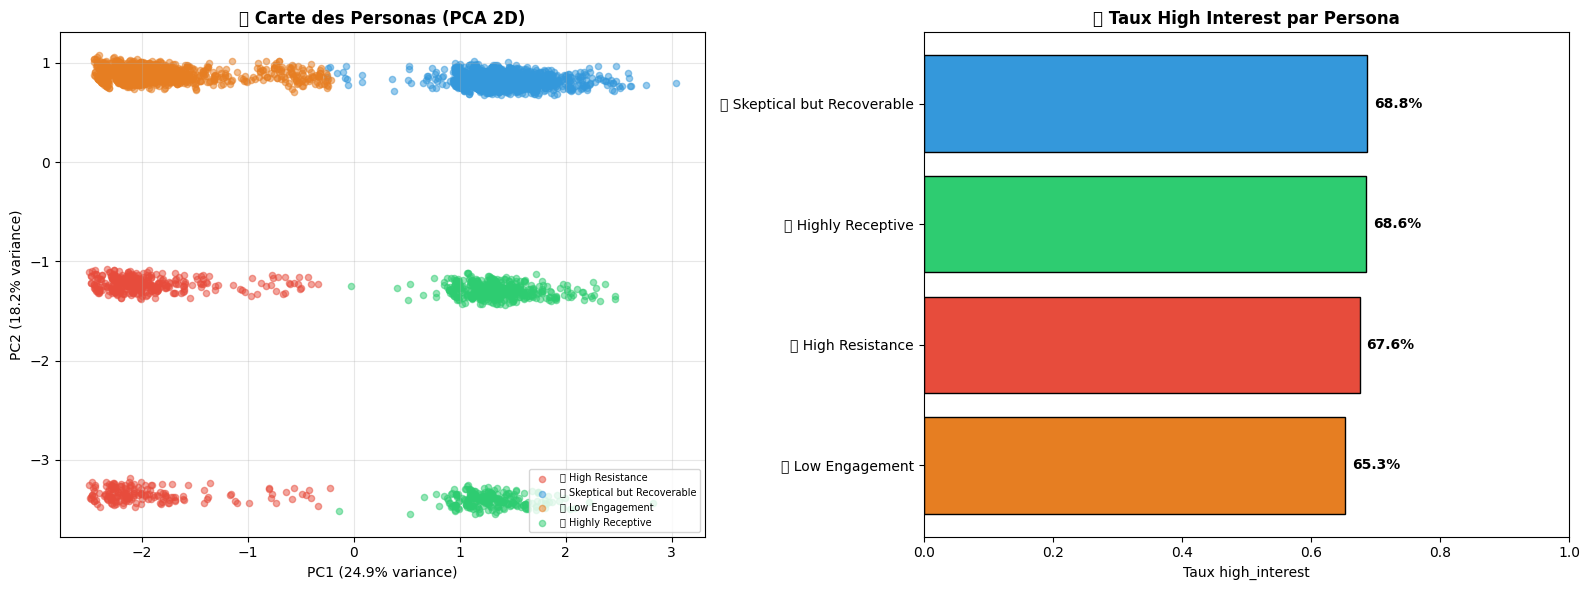


📋 RÉSUMÉ DES PERSONAS
                             nb_visites  avg_interest  pct_high_interest  pct_retissant  pct_satisfait
persona_name                                                                                          
🔴 High Resistance                   518          3.68               0.68           0.23           0.37
🔵 Skeptical but Recoverable        1680          3.72               0.69           0.22           0.39
🟠 Low Engagement                   1215          3.66               0.65           0.21           0.35
🟢 Highly Receptive                  723          3.76               0.69           0.21           0.41

✅ Étape 7 terminée !


In [ ]:
# ==============================
# ÉTAPE 7 — Visualisation finale des Personas
# ==============================

# ✅ FIX : X_scaled a même index que df (fillna(0) préserve l'index)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_viz = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'persona_cluster': df['persona_cluster'].values,
    'persona_name':    df['persona_name'].values,
    'high_interest':   df['high_interest'].values,
})

# ✅ k=3 → 3 personas uniquement
persona_colors = {
    '🟢 Highly Receptive': '#2ecc71',
    '🔴 High Resistance':  '#e74c3c',
    '🟠 Low Engagement':   '#e67e22',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, group in df_viz.groupby('persona_name'):
    axes[0].scatter(group['PC1'], group['PC2'],
                    label=name, alpha=0.5, s=20,
                    color=persona_colors.get(name, '#95a5a6'))
axes[0].set_title('🗺️ Carte des Personas (PCA 2D)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].legend(fontsize=7, loc='best')
axes[0].grid(True, alpha=0.3)

hi_rate = df.groupby('persona_name')['high_interest'].mean().sort_values(ascending=True)
colors_bar = [persona_colors.get(n, '#95a5a6') for n in hi_rate.index]
bars = axes[1].barh(hi_rate.index, hi_rate.values, color=colors_bar, edgecolor='black')
axes[1].set_title('🎯 Taux High Interest par Persona', fontweight='bold')
axes[1].set_xlabel('Taux high_interest')
axes[1].set_xlim(0, 1)
for bar, val in zip(bars, hi_rate.values):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.1%}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('personas_viz.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n" + "="*55)
print("📋 RÉSUMÉ DES PERSONAS")
print("="*55)
summary = df.groupby('persona_name').agg(
    nb_visites        = ('persona_cluster','count'),
    avg_interest      = ('niveau_interet','mean'),
    pct_high_interest = ('high_interest','mean'),
    pct_retissant     = ('flag_retissant','mean'),
    pct_satisfait     = ('flag_satisfait','mean'),
).round(2)
print(summary.to_string())
print("\n✅ Étape 7 terminée !")


## ÉTAPE 8 — Physician Persona Card


In [ ]:
# ==============================
# ÉTAPE 8 — Physician Persona Card
# ==============================

strategy_map = {
    '🟢 Highly Receptive':          'Consolidate relationship — share new clinical data and propose a follow-up visit.',
    '🔴 High Resistance':           'Handle objections — share tolerance evidence and schedule a short focused visit.',
    '🟡 Routine-Oriented':          'Strengthen routine — reinforce key benefits and confirm dosage protocols.',
    '🟠 Low Engagement':            'Re-engage — offer product trial, invite to medical event, or escalate to manager.',
    '🔵 Skeptical but Recoverable': 'Build trust — use peer references, case studies, and propose a demo visit.',
}

objection_map = {
    '🟢 Highly Receptive':          'Occasional questions on clinical studies',
    '🔴 High Resistance':           'Tolerance / side effects / competition',
    '🟡 Routine-Oriented':          'No major objections — routine follow-up',
    '🟠 Low Engagement':            'Availability / interest in new products',
    '🔵 Skeptical but Recoverable': 'Efficacy doubts / needs more evidence',
}

def generate_persona_card(doctor_name):
    rows = df[df['nom_medecin'] == doctor_name]
    if rows.empty:
        print(f"❌ Médecin '{doctor_name}' introuvable.")
        return

    r        = rows.iloc[0]
    persona  = r['persona_name']
    avg_int  = rows['niveau_interet'].mean()
    nb_vis   = len(rows)
    pct_hi   = rows['high_interest'].mean()
    top_med  = rows['medicament'].value_counts().index[0]
    specialty= r['specialite_medecin']
    strategy = strategy_map.get(persona, 'Personalized follow-up recommended.')
    objection= objection_map.get(persona, 'N/A')

    # ✅ FIX : tronquer les champs longs pour éviter le débordement
    doc_disp  = doctor_name[:40]
    spec_disp = str(specialty)[:40]
    med_disp  = str(top_med)[:40]
    obj_disp  = objection[:55]
    strat1    = strategy[:55]
    strat2    = strategy[55:110]

    card = f"""
╔══════════════════════════════════════════════════════════════╗
║              🏥  PHYSICIAN PERSONA CARD — ALIA-CRM           ║
╠══════════════════════════════════════════════════════════════╣
║  👨‍⚕️  Doctor      : {doc_disp:<40} ║
║  🏥  Specialty   : {spec_disp:<40} ║
║  💊  Top Product : {med_disp:<40} ║
╠══════════════════════════════════════════════════════════════╣
║  🎭  PERSONA     : {str(persona):<40} ║
╠══════════════════════════════════════════════════════════════╣
║  📊  Avg Interest       : {avg_int:.2f} / 5.00                        ║
║  📅  Total Visits       : {nb_vis:<36} ║
║  🎯  High Interest Rate : {pct_hi*100:.1f}%                            ║
╠══════════════════════════════════════════════════════════════╣
║  ⚠️   Frequent Objection :                                    ║
║      {obj_disp:<55} ║
╠══════════════════════════════════════════════════════════════╣
║  ✅  Recommended Next Action :                                ║
║      {strat1:<55} ║
║      {strat2:<55} ║
╚══════════════════════════════════════════════════════════════╝
"""
    print(card)

# Demo
print("="*65)
print("🔎  DEMO : INPUT → OUTPUT pour le Jury")
print("="*65)
print("\n📥 INPUT : 'Dr Ahmed Ben Youssef'")
print("📤 OUTPUT :\n")
generate_persona_card('Dr Ahmed Ben Youssef')

print("\n" + "-"*65)
print("📥 INPUT : 'Dr Rania Khelifi'")
print("📤 OUTPUT :\n")
generate_persona_card('Dr Rania Khelifi')

print("\n✅ Étape 8 terminée !")


🔎  DEMO : INPUT → OUTPUT pour le Jury

📥 INPUT : 'Dr Ahmed Ben Youssef'
📤 OUTPUT :


╔══════════════════════════════════════════════════════════════╗
║              🏥  PHYSICIAN PERSONA CARD — ALIA-CRM           ║
╠══════════════════════════════════════════════════════════════╣
║  👨‍⚕️  Doctor      : Dr Ahmed Ben Youssef                     ║
║  🏥  Specialty   : Cardiologie                              ║
║  💊  Top Product : accutane                                 ║
╠══════════════════════════════════════════════════════════════╣
║  🎭  PERSONA     : 🟢 Highly Receptive                       ║
╠══════════════════════════════════════════════════════════════╣
║  📊  Avg Interest       : 3.74 / 5.00                        ║
║  📅  Total Visits       : 415                                  ║
║  🎯  High Interest Rate : 67.2%                            ║
╠══════════════════════════════════════════════════════════════╣
║  ⚠️   Frequent Objection :                                    ║
║      Occasi

## 🔗 ÉTAPE 9 — Intégration NBA (Next Best Action)


In [ ]:
# ==============================
# ÉTAPE 9 — Intégration Next Best Action (NBA)
# depuis le notebook de ton amie
# ==============================

# On recrée les fonctions NBA directement ici
# (sans avoir besoin d'importer le fichier .joblib)

import unicodedata, re

def normalize_text(text):
    if pd.isna(text): return ""
    text = str(text).lower().strip()
    text = unicodedata.normalize("NFKD", text)
    text = "".join([c for c in text if not unicodedata.combining(c)])
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ── Modèle I : Recommandation Commerciale (rule-based) ──────────
positive_keywords = [
    "efficace","tres efficace","amelioration","ameliore","soulage",
    "excellent","bon resultat","recommande","satisfait","stabilise","controle bien"
]
negative_keywords = [
    "inefficace","pas efficace","mauvais resultat","decevant",
    "ne fonctionne pas","aucun effet","abandonne"
]

def keyword_score(text):
    text = normalize_text(text)
    pos = sum(1 for kw in positive_keywords if kw in text)
    neg = sum(1 for kw in negative_keywords if kw in text)
    return pos - neg

effectiveness_map = {
    "Très efficace": 3, "Considérablement efficace": 2,
    "Modérément efficace": 1, "Marginalement efficace": 0,
    "Inefficacité": -2, "Inefficace": -2
}

def predict_commercial_label(rating, effectiveness, benefits="", comments=""):
    text = normalize_text(benefits) + " " + normalize_text(comments)
    eff  = effectiveness_map.get(effectiveness, 0)
    kw   = keyword_score(text)
    if (rating >= 8 and eff >= 2) or (rating >= 9 and kw >= 1):
        return "Fort potentiel commercial"
    if (rating <= 4) or (eff <= -2) or (kw <= -1):
        return "Faible potentiel commercial"
    return "Potentiel à développer"

def map_commercial_to_actions(label):
    if label == "Fort potentiel commercial":
        return ["✅ Proposer des échantillons",
                "📅 Planifier un essai avec le médecin"]
    elif label == "Potentiel à développer":
        return ["📄 Laisser une documentation explicative",
                "📞 Prévoir un appel de suivi dans 2 semaines"]
    else:
        return ["⚠️ Identifier les freins et objections principales",
                "🔄 Repositionner le produit ou proposer une alternative"]

# ── Modèle II : Analyse du Risque (rule-based) ──────────────────
high_risk_keywords   = ["grave","choc","allergie severe","hospitalisation","urgence","dangereux"]
medium_risk_keywords = ["nausee","vomissement","fatigue","somnolence","douleur","insomnie","vertige"]
low_risk_keywords    = ["leger","faible","tolerable","bonne tolerance","bien tolere","aucun probleme"]

sideeffects_score_map = {
    "Aucun effet secondaire": 0,
    "Pas d'effets secondaires": 0,
    "Effets secondaires légers": 1,
    "Effets secondaires modérés": 2,
    "Effets secondaires graves": 3,
    "Effets secondaires extrêmement graves": 4
}

def predict_risk_label(side_effects, side_review=""):
    text  = normalize_text(side_effects) + " " + normalize_text(side_review)
    score = sideeffects_score_map.get(side_effects, 0)
    high  = sum(1 for kw in high_risk_keywords   if kw in text)
    med   = sum(1 for kw in medium_risk_keywords  if kw in text)
    low   = sum(1 for kw in low_risk_keywords     if kw in text)
    if score >= 3 or high >= 1:   return "Risque élevé"
    if score <= 0 and low >= 1:   return "Risque faible"
    return "Risque modéré"

def map_risk_to_actions(label):
    if label == "Risque faible":
        return ["✅ Maintenir le traitement avec surveillance simple",
                "📋 Conseiller de suivre l'évolution des symptômes"]
    elif label == "Risque modéré":
        return ["⚠️ Adapter les conditions de prise (dose, moment)",
                "📞 Prévoir un suivi médical rapproché"]
    else:
        return ["🚨 Arrêt immédiat et consultation médicale urgente",
                "📝 Déclarer l'effet indésirable au pharmacovigilant"]

print("✅ Fonctions NBA chargées avec succès !")

✅ Fonctions NBA chargées avec succès !


## ÉTAPE 10 — Persona Card COMPLÈTE avec NBA intégrée


In [ ]:
# ==============================
# ÉTAPE 10 — Persona Card COMPLÈTE (HCP + NBA)
# ==============================

def generate_full_persona_card(doctor_name, rating=7,
                                effectiveness="Modérément efficace",
                                benefits="", comments="",
                                side_effects="Effets secondaires légers",
                                side_review=""):

    rows = df[df['nom_medecin'] == doctor_name]
    if rows.empty:
        print(f"❌ Médecin '{doctor_name}' introuvable.")
        return

    r         = rows.iloc[0]
    persona   = r['persona_name']
    avg_int   = rows['doctor_avg_interest'].mean()
    nb_vis    = len(rows)
    pct_hi    = rows['high_interest'].mean()
    top_med   = rows['medicament'].value_counts().index[0]
    specialty = r['specialite_medecin']

    # HCP strategy (Étape 8)
    hcp_action   = strategy_map.get(persona, 'Personalized follow-up recommended.')
    hcp_objection= objection_map.get(persona, 'N/A')

    # NBA Modèle I — Commercial
    com_label   = predict_commercial_label(rating, effectiveness, benefits, comments)
    com_actions = map_commercial_to_actions(com_label)

    # NBA Modèle II — Risque
    risk_label   = predict_risk_label(side_effects, side_review)
    risk_actions = map_risk_to_actions(risk_label)

    print(f"""
╔══════════════════════════════════════════════════════════════════╗
║          🏥  ALIA-CRM — PHYSICIAN FULL INTELLIGENCE CARD         ║
╠══════════════════════════════════════════════════════════════════╣
║  👨‍⚕️  Doctor     : {doctor_name:<45} ║
║  🏥  Specialty  : {specialty:<45} ║
║  💊  Top Product: {top_med:<45} ║
╠══════════════════════════════════════════════════════════════════╣
║  🎭  HCP PERSONA : {persona:<44} ║
║  📊  Avg Interest      : {avg_int:.2f}/5  |  Visits: {nb_vis}  |  High Interest: {pct_hi*100:.0f}%  ║
║  ⚠️   Frequent Objection: {hcp_objection[:45]:<45} ║
║  🎯  HCP Strategy      : {hcp_action[:45]:<45} ║
╠══════════════════════════════════════════════════════════════════╣
║  💼  NBA — RECOMMANDATION COMMERCIALE                            ║
║  Label : {com_label:<54} ║
║  Actions :                                                       ║
║    {com_actions[0][:62]:<62} ║
║    {com_actions[1][:62]:<62} ║
╠══════════════════════════════════════════════════════════════════╣
║  🧬  NBA — ANALYSE DU RISQUE                                     ║
║  Label : {risk_label:<54} ║
║  Actions :                                                       ║
║    {risk_actions[0][:62]:<62} ║
║    {risk_actions[1][:62]:<62} ║
╚══════════════════════════════════════════════════════════════════╝
""")

# ── DEMO LIVE ────────────────────────────────────────────────────
print("="*68)
print("  🔎  INPUT → OUTPUT DEMO — ALIA-CRM Full Intelligence")
print("="*68)

print("\n📥 INPUT :")
print("   Médecin    : Dr Ahmed Ben Youssef")
print("   Rating     : 8/10")
print("   Efficacité : Très efficace")
print("   Bénéfices  : Bonne amélioration, patient satisfait")
print("   Effets sec.: Effets secondaires légers")

print("\n📤 OUTPUT :\n")
generate_full_persona_card(
    doctor_name  = "Dr Ahmed Ben Youssef",
    rating       = 8,
    effectiveness= "Très efficace",
    benefits     = "Bonne amélioration, patient satisfait",
    comments     = "Traitement bien toléré",
    side_effects = "Effets secondaires légers",
    side_review  = "légères nausées passagères"
)

  🔎  INPUT → OUTPUT DEMO — ALIA-CRM Full Intelligence

📥 INPUT :
   Médecin    : Dr Ahmed Ben Youssef
   Rating     : 8/10
   Efficacité : Très efficace
   Bénéfices  : Bonne amélioration, patient satisfait
   Effets sec.: Effets secondaires légers

📤 OUTPUT :


╔══════════════════════════════════════════════════════════════════╗
║          🏥  ALIA-CRM — PHYSICIAN FULL INTELLIGENCE CARD         ║
╠══════════════════════════════════════════════════════════════════╣
║  👨‍⚕️  Doctor     : Dr Ahmed Ben Youssef                          ║
║  🏥  Specialty  : Cardiologie                                   ║
║  💊  Top Product: accutane                                      ║
╠══════════════════════════════════════════════════════════════════╣
║  🎭  HCP PERSONA : 🟢 Highly Receptive                           ║
║  📊  Avg Interest      : 3.74/5  |  Visits: 415  |  High Interest: 67%  ║
║  ⚠️   Frequent Objection: Occasional questions on clinical studies      ║
║  🎯  HCP Strategy      : Consolidate re

## ÉTAPE 11 — Widget interactif COMPLET


In [ ]:
# ==============================
# ÉTAPE 11 — Widget Full NBA + HCP (DEMO JURY)
# ==============================
import ipywidgets as widgets
from IPython.display import display, clear_output

doctor_list = sorted(df['nom_medecin'].unique().tolist())

# Inputs
w_doctor = widgets.Dropdown(
    options=doctor_list, description='👨‍⚕️ Médecin :',
    style={'description_width':'initial'},
    layout=widgets.Layout(width='380px'))

w_rating = widgets.IntSlider(
    value=7, min=1, max=10, step=1,
    description='⭐ Rating :',
    style={'description_width':'initial'},
    layout=widgets.Layout(width='380px'))

w_eff = widgets.Dropdown(
    options=list(effectiveness_map.keys()),
    value="Modérément efficace",
    description='💊 Efficacité :',
    style={'description_width':'initial'},
    layout=widgets.Layout(width='380px'))

w_side = widgets.Dropdown(
    options=list(sideeffects_score_map.keys()),
    value="Effets secondaires légers",
    description='⚠️ Effets sec. :',
    style={'description_width':'initial'},
    layout=widgets.Layout(width='380px'))

w_benefits = widgets.Text(
    placeholder='Ex: Patient amélioré, bons résultats...',
    description='✅ Bénéfices :',
    style={'description_width':'initial'},
    layout=widgets.Layout(width='500px'))

w_side_review = widgets.Text(
    placeholder='Ex: légères nausées passagères...',
    description='🧬 Détail effets:',
    style={'description_width':'initial'},
    layout=widgets.Layout(width='500px'))

btn = widgets.Button(
    description='⚡ Générer Intelligence Card',
    button_style='success',
    layout=widgets.Layout(width='300px', height='45px'))

output = widgets.Output()

def on_click(b):
    with output:
        clear_output()
        generate_full_persona_card(
            doctor_name  = w_doctor.value,
            rating       = w_rating.value,
            effectiveness= w_eff.value,
            benefits     = w_benefits.value,
            side_effects = w_side.value,
            side_review  = w_side_review.value
        )

btn.on_click(on_click)

print("="*60)
print("  🏥  ALIA-CRM — Full Intelligence Card  |  LIVE DEMO")
print("="*60)
display(widgets.VBox([
    w_doctor, w_rating, w_eff, w_side,
    w_benefits, w_side_review, btn, output
]))

  🏥  ALIA-CRM — Full Intelligence Card  |  LIVE DEMO
